# Papaloizou-Pringle Accretion Disk: Scale Calculations

Calculates all physical scales for the Papaloizou-Pringle disk model implementation in Athena++.

**References:** `materials/theory/theory.txt`, `src/pgen/acc_disk.cpp`

## 1. Input Parameters

Set the fundamental parameters for your disk model:
- **M_BH**: Black hole mass
- **r_max**: Distance to disk center (where density peaks)
- **C_prime**: Disk width parameter (0.4-0.5 for moderate thickness)
- **gamma**: Adiabatic index
- **nu_tilde**: Dimensionless kinematic viscosity

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Physical Constants (CGS)
c = 2.99792458e10       # Speed of light [cm/s]
G = 6.67430e-8          # Gravitational constant [cm³/(g·s²)]
M_sun = 1.98847e33      # Solar mass [g]
k_B = 1.380649e-16      # Boltzmann constant [erg/K]
m_p = 1.6726219e-24     # Proton mass [g]
pc = 3.086e18           # Parsec [cm]
AU = 1.496e13           # Astronomical unit [cm]
year_to_sec = 365.25 * 24 * 3600
day_to_sec = 24 * 3600

# ==================== INPUT PARAMETERS ====================

# Black hole mass
M_BH_solar = 21      # [M_sun]

# Distance to disk center (radius of maximum density)
# Choose ONE of the following methods:
input_mode = 'chi'      # Options: 'chi', 'pc', 'cm'

if input_mode == 'chi':
    chi = 100.0        # Dimensionless scaling parameter
    r_max = None        # Will be calculated
elif input_mode == 'pc':
    r_max_pc = 0.01     # [pc]
    r_max = r_max_pc * pc
    chi = None          # Will be calculated
elif input_mode == 'cm':
    r_max_cm = 3.0e17   # [cm]
    r_max = r_max_cm
    chi = None          # Will be calculated

# Disk parameters
C_prime = 0.30          # Disk width parameter (0.4-0.5 typical)
gamma = 5/3             # Adiabatic index (5/3: ideal gas, 4/3: relativistic)
nu_tilde = 1.0e-3       # Dimensionless viscosity (10^-4 to 10^-2 typical)

# ==========================================================

print("="*70)
print("INPUT PARAMETERS")
print("="*70)
print(f"Black hole mass:     M_BH = {M_BH_solar:.2e} M_sun")
print(f"Input mode:          {input_mode}")
if input_mode == 'chi':
    print(f"Scaling parameter:   χ = {chi}")
elif input_mode == 'pc':
    print(f"Disk center radius:  r_max = {r_max_pc} pc")
elif input_mode == 'cm':
    print(f"Disk center radius:  r_max = {r_max_cm:.2e} cm")
print(f"Disk width param:    C' = {C_prime}")
print(f"Adiabatic index:     γ = {gamma:.4f}")
print(f"Viscosity:           ν̃ = {nu_tilde:.4e}")
print("="*70)

INPUT PARAMETERS
Black hole mass:     M_BH = 2.10e+01 M_sun
Input mode:          chi
Scaling parameter:   χ = 100.0
Disk width param:    C' = 0.3
Adiabatic index:     γ = 1.6667
Viscosity:           ν̃ = 1.0000e-03


## 2. Calculate Fundamental Scales

Calculate gravitational radius and characteristic scales based on input parameters.

In [56]:
# Convert mass to CGS
M_BH = M_BH_solar * M_sun

# Gravitational radius
r_g = (2 * G * M_BH) / (c**2)

# Determine chi and r_0 based on input mode
if input_mode == 'chi':
    r_0 = chi * r_g
elif input_mode in ['pc', 'cm']:
    r_0 = r_max
    chi = r_0 / r_g

# Characteristic scales (Equations from theory.txt)
v_0 = c / np.sqrt(2 * chi)                          # Characteristic velocity
t_0 = 2 * np.pi * np.sqrt(r_0**3 / (G * M_BH))     # Orbital period at r_0
n = 1.0 / (gamma - 1.0)                            # Polytropic index

print("="*70)
print("CHARACTERISTIC SCALES")
print("="*70)
print(f"Gravitational radius: r_g  = {r_g:.4e} cm = {r_g/AU:.4f} AU")
print(f"Scaling parameter:    χ    = {chi:.2f}")
print(f"Characteristic length: r_0  = {r_0:.4e} cm = {r_0/AU:.2f} AU = {r_0/pc:.4e} pc")
print(f"Characteristic velocity: v_0 = {v_0:.4e} cm/s = {v_0/c:.6f} c")
print(f"Orbital period at r_0: t_0  = {t_0:.4e} s = {t_0/day_to_sec:.2f} days")
print(f"Polytropic index:     n    = {n:.4f}")
print("="*70)

CHARACTERISTIC SCALES
Gravitational radius: r_g  = 6.2020e+06 cm = 0.0000 AU
Scaling parameter:    χ    = 100.00
Characteristic length: r_0  = 6.2020e+08 cm = 0.00 AU = 2.0097e-10 pc
Characteristic velocity: v_0 = 2.1199e+09 cm/s = 0.070711 c
Orbital period at r_0: t_0  = 1.8383e+00 s = 0.00 days
Polytropic index:     n    = 1.5000


## 3. Disk Structure

Calculate disk boundaries and equilibrium profiles using the Papaloizou-Pringle formula:

$$\frac{\tilde{p}}{\tilde{\rho}} = \frac{1}{n+1}\left(\frac{1}{\tilde{r}} - \frac{1}{2\tilde{r}^2} - C'\right)$$

In [57]:
def disk_function(r_tilde, C_prime):
    """Disk equilibrium function. Disk exists where f > 0."""
    return 1.0/r_tilde - 1.0/(2.0*r_tilde**2) - C_prime

def find_disk_edges(C_prime):
    """Find inner and outer disk edges by solving f(r̃) = 0."""
    a = 1.0
    b = -1.0/C_prime
    c = 1.0/(2.0*C_prime)
    discriminant = b**2 - 4*a*c
    if discriminant < 0:
        return None, None
    r_inner = (-b - np.sqrt(discriminant)) / (2*a)
    r_outer = (-b + np.sqrt(discriminant)) / (2*a)
    return r_inner, r_outer

def calculate_disk_profile(r_tilde, C_prime, n, gamma, density_floor=1e-8):
    """Calculate all physical quantities for the equilibrium disk."""
    f_center = disk_function(1.0, C_prime)
    p_over_rho_center = f_center / (n + 1.0)
    f = disk_function(r_tilde, C_prime)
    
    if f > 0:  # Inside disk
        p_over_rho = f / (n + 1.0)
        rho_tilde = (p_over_rho / p_over_rho_center)**(1.0/(gamma-1.0))
        p_tilde = rho_tilde * p_over_rho
        v_r = 0.0
        v_phi = 1.0 / np.sqrt(r_tilde)  # Keplerian
    else:  # Outside disk
        rho_tilde = density_floor
        p_tilde = density_floor * p_over_rho_center
        v_r = 0.0
        v_phi = 1.0 / np.sqrt(r_tilde)
    
    kinetic_energy = 0.5 * rho_tilde * (v_r**2 + v_phi**2)
    internal_energy = p_tilde / (gamma - 1.0)
    E_total = internal_energy + kinetic_energy
    
    return rho_tilde, v_r, v_phi, p_tilde, p_tilde/rho_tilde, E_total

# Find disk boundaries
r_inner, r_outer = find_disk_edges(C_prime)

# Generate radial profiles
r_profile = np.linspace(0.3, 3.0, 500)
profiles = [calculate_disk_profile(r, C_prime, n, gamma) for r in r_profile]
rho_profile = np.array([p[0] for p in profiles])
vr_profile = np.array([p[1] for p in profiles])
vphi_profile = np.array([p[2] for p in profiles])
p_profile = np.array([p[3] for p in profiles])
T_profile = np.array([p[4] for p in profiles])
E_profile = np.array([p[5] for p in profiles])

print("="*70)
print("DISK STRUCTURE")
print("="*70)
print(f"Inner edge:  r̃_in  = {r_inner:.4f} ({r_inner*r_0/AU:.3f} AU)")
print(f"Outer edge:  r̃_out = {r_outer:.4f} ({r_outer*r_0/AU:.3f} AU)")
print(f"Disk width:  Δr̃    = {r_outer-r_inner:.4f}")
print("="*70)

DISK STRUCTURE
Inner edge:  r̃_in  = 0.6126 (0.000 AU)
Outer edge:  r̃_out = 2.7208 (0.000 AU)
Disk width:  Δr̃    = 2.1082


## 4. Viscosity and Timescales

Calculate viscous timescale and equivalent α-parameter.

In [58]:
# Physical viscosity
nu_physical = nu_tilde * r_0 * v_0

# Viscous timescale
tau_visc_code = 1.0 / nu_tilde
tau_visc_physical = tau_visc_code * t_0

# Equivalent alpha parameter at r̃ = 1
p_over_rho_center = disk_function(1.0, C_prime) / (n + 1.0)
alpha_equiv = nu_tilde / (gamma * p_over_rho_center * 1.0**(3.0/2.0))

print("="*70)
print("VISCOSITY & TIMESCALES")
print("="*70)
print(f"Kinematic viscosity:  ν  = {nu_physical:.4e} cm²/s")
print(f"                      ν̃  = {nu_tilde:.4e} (code units)")
print(f"Viscous timescale:    τ_visc = {tau_visc_physical:.4e} s")
print(f"                           = {tau_visc_physical/day_to_sec:.2f} days")
print(f"                           = {tau_visc_code:.1f} orbits")
print(f"Equivalent α-param:   α_equiv ≈ {alpha_equiv:.4f}")
print("="*70)

VISCOSITY & TIMESCALES
Kinematic viscosity:  ν  = 1.3147e+15 cm²/s
                      ν̃  = 1.0000e-03 (code units)
Viscous timescale:    τ_visc = 1.8383e+03 s
                           = 0.02 days
                           = 1000.0 orbits
Equivalent α-param:   α_equiv ≈ 0.0075


## 5. Simulation Parameters

Recommended parameters for Athena++ input file.

In [59]:
# Simulation parameters
nx1, nx2, nx3 = 256, 256, 1
x1min, x1max = 0.3, 3.0
x2min, x2max = 0.0, 2*np.pi
cfl = 0.3
tlim_code = 2.0 * tau_visc_code
dt_output = tau_visc_code / 25.0
dfloor, pfloor = 1.0e-8, 1.0e-10

print("="*70)
print("SIMULATION PARAMETERS")
print("="*70)
print(f"\n<mesh>")
print(f"  nx1={nx1}, nx2={nx2}, nx3={nx3}")
print(f"  x1min={x1min}, x1max={x1max}")
print(f"  x2min={x2min}, x2max={x2max:.10f}")
print(f"\n<time>")
print(f"  cfl_number={cfl}")
print(f"  tlim={tlim_code:.2f}  # {tlim_code*t_0/day_to_sec:.1f} days, {tlim_code/tau_visc_code:.1f} visc. times")
print(f"\n<hydro>")
print(f"  gamma={gamma:.10f}")
print(f"  nu_iso={nu_tilde:.6f}")
print(f"  dfloor={dfloor:.2e}, pfloor={pfloor:.2e}")
print(f"\n<problem>")
print(f"  chi={chi:.2f}")
print(f"  C_prime={C_prime}")
print("="*70)

SIMULATION PARAMETERS

<mesh>
  nx1=256, nx2=256, nx3=1
  x1min=0.3, x1max=3.0
  x2min=0.0, x2max=6.2831853072

<time>
  cfl_number=0.3
  tlim=2000.00  # 0.0 days, 2.0 visc. times

<hydro>
  gamma=1.6666666667
  nu_iso=0.001000
  dfloor=1.00e-08, pfloor=1.00e-10

<problem>
  chi=100.00
  C_prime=0.3


## 6. Visualization

Plot all disk profiles.

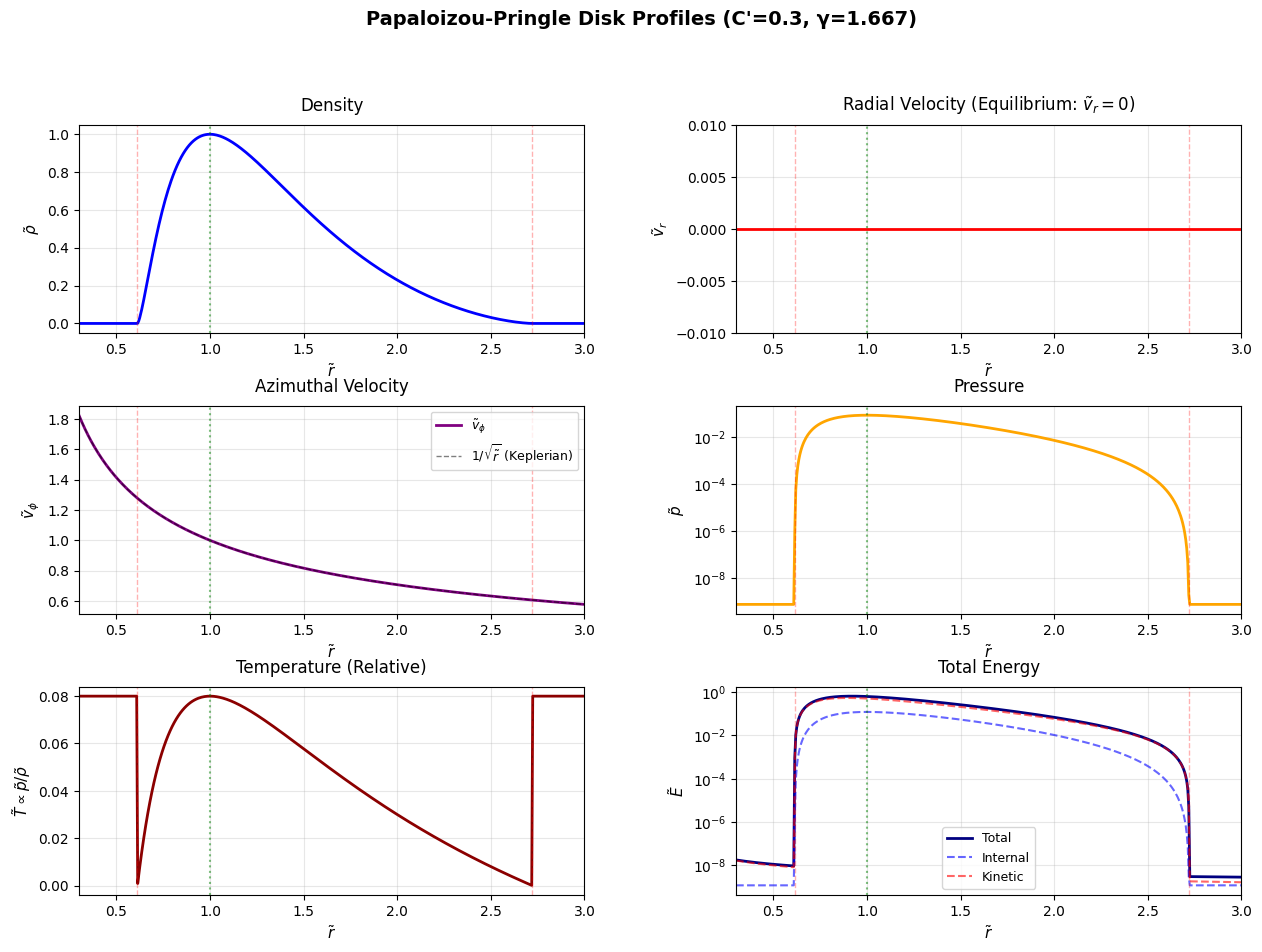

✓ Saved: disk_profiles.png


In [60]:
# Set better style
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# Helper function to add disk boundaries
def add_boundaries(ax):
    ax.axvline(r_inner, color='r', linestyle='--', alpha=0.3, linewidth=1)
    ax.axvline(r_outer, color='r', linestyle='--', alpha=0.3, linewidth=1)
    ax.axvline(1.0, color='g', linestyle=':', alpha=0.5, linewidth=1.5)

# 1. Density
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(r_profile, rho_profile, 'b-', linewidth=2)
add_boundaries(ax1)
ax1.set_xlabel(r'$\tilde{r}$', fontsize=11)
ax1.set_ylabel(r'$\tilde{\rho}$', fontsize=11)
ax1.set_title('Density', fontsize=12, pad=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.3, 3.0)

# 2. Radial velocity
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(r_profile, vr_profile, 'r-', linewidth=2)
add_boundaries(ax2)
ax2.set_xlabel(r'$\tilde{r}$', fontsize=11)
ax2.set_ylabel(r'$\tilde{v}_r$', fontsize=11)
ax2.set_title('Radial Velocity (Equilibrium: $\\tilde{v}_r=0$)', fontsize=12, pad=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.3, 3.0)
ax2.set_ylim(-0.01, 0.01)

# 3. Azimuthal velocity
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(r_profile, vphi_profile, 'purple', linewidth=2, label=r'$\tilde{v}_\phi$')
ax3.plot(r_profile, 1.0/np.sqrt(r_profile), 'k--', linewidth=1, alpha=0.5, 
         label=r'$1/\sqrt{\tilde{r}}$ (Keplerian)')
add_boundaries(ax3)
ax3.set_xlabel(r'$\tilde{r}$', fontsize=11)
ax3.set_ylabel(r'$\tilde{v}_\phi$', fontsize=11)
ax3.set_title('Azimuthal Velocity', fontsize=12, pad=10)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=9, loc='upper right')
ax3.set_xlim(0.3, 3.0)

# 4. Pressure
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(r_profile, p_profile, 'orange', linewidth=2)
add_boundaries(ax4)
ax4.set_xlabel(r'$\tilde{r}$', fontsize=11)
ax4.set_ylabel(r'$\tilde{p}$', fontsize=11)
ax4.set_title('Pressure', fontsize=12, pad=10)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.3, 3.0)
ax4.set_yscale('log')

# 5. Temperature
ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(r_profile, T_profile, 'darkred', linewidth=2)
add_boundaries(ax5)
ax5.set_xlabel(r'$\tilde{r}$', fontsize=11)
ax5.set_ylabel(r'$\tilde{T} \propto \tilde{p}/\tilde{\rho}$', fontsize=11)
ax5.set_title('Temperature (Relative)', fontsize=12, pad=10)
ax5.grid(True, alpha=0.3)
ax5.set_xlim(0.3, 3.0)

# 6. Total energy
ax6 = fig.add_subplot(gs[2, 1])
E_internal = p_profile / (gamma - 1.0)
E_kinetic = 0.5 * rho_profile * vphi_profile**2
ax6.plot(r_profile, E_profile, 'navy', linewidth=2, label='Total')
ax6.plot(r_profile, E_internal, 'b--', linewidth=1.5, alpha=0.6, label='Internal')
ax6.plot(r_profile, E_kinetic, 'r--', linewidth=1.5, alpha=0.6, label='Kinetic')
add_boundaries(ax6)
ax6.set_xlabel(r'$\tilde{r}$', fontsize=11)
ax6.set_ylabel(r'$\tilde{E}$', fontsize=11)
ax6.set_title('Total Energy', fontsize=12, pad=10)
ax6.grid(True, alpha=0.3)
ax6.legend(fontsize=9, loc='best')
ax6.set_xlim(0.3, 3.0)
ax6.set_yscale('log')

plt.suptitle(f'Papaloizou-Pringle Disk Profiles (C\'={C_prime}, γ={gamma:.3f})', 
             fontsize=14, fontweight='bold', y=0.995)

plt.savefig('/home/etrevol/athena-collab/materials/theory-scripts/disk_profiles.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: disk_profiles.png")

## 7. Summary Tables

Export all parameters to CSV tables.

In [61]:
# Table 1: Physical Parameters
physical_params = pd.DataFrame({
    'Parameter': ['Black Hole Mass', 'Gravitational Radius', 'Scaling Parameter', 
                  'Characteristic Length', 'Characteristic Velocity', 'Orbital Period'],
    'Symbol': ['M_BH', 'r_g', 'χ', 'r₀', 'v₀', 't₀'],
    'Value': [f'{M_BH/M_sun:.2e}', f'{r_g:.4e}', f'{chi:.2f}', 
              f'{r_0:.4e}', f'{v_0:.4e}', f'{t_0:.4e}'],
    'Units': ['M☉', 'cm', '—', 'cm', 'cm/s', 's'],
    'Alternative': [f'{M_BH:.4e} g', f'{r_g/AU:.4f} AU', '—',
                   f'{r_0/AU:.2f} AU', f'{v_0/c:.6f} c', f'{t_0/day_to_sec:.2f} days']
})

# Table 2: Disk Parameters
disk_params = pd.DataFrame({
    'Parameter': ['Adiabatic Index', 'Polytropic Index', 'Width Parameter',
                  'Inner Edge', 'Outer Edge', 'Disk Width'],
    'Symbol': ['γ', 'n', "C'", 'r̃_inner', 'r̃_outer', 'Δr̃'],
    'Value': [f'{gamma:.6f}', f'{n:.4f}', f'{C_prime:.3f}',
              f'{r_inner:.4f}', f'{r_outer:.4f}', f'{r_outer-r_inner:.4f}'],
    'Physical': ['', f'n=1/(γ-1)', 'thickness',
                f'{r_inner*r_0/AU:.3f} AU', f'{r_outer*r_0/AU:.3f} AU', '']
})

# Table 3: Viscosity
visc_params = pd.DataFrame({
    'Parameter': ['Kinematic Viscosity', 'Viscous Timescale', 'Equivalent α'],
    'Symbol': ['ν̃', 'τ_visc', 'α_equiv'],
    'Code Units': [f'{nu_tilde:.4e}', f'{tau_visc_code:.1f}', f'{alpha_equiv:.4f}'],
    'Physical': [f'{nu_physical:.4e} cm²/s', 
                f'{tau_visc_physical/day_to_sec:.1f} days', 'reference']
})

# Display
print("="*80)
print("SUMMARY TABLES")
print("="*80)
print("\n■ Physical Parameters\n")
print(physical_params.to_string(index=False))
print("\n\n■ Disk Structure\n")
print(disk_params.to_string(index=False))
print("\n\n■ Viscosity & Timescales\n")
print(visc_params.to_string(index=False))
print("="*80)

# Save to CSV
physical_params.to_csv('/home/etrevol/athena-collab/materials/theory-scripts/params_physical.csv', index=False)
disk_params.to_csv('/home/etrevol/athena-collab/materials/theory-scripts/params_disk.csv', index=False)
visc_params.to_csv('/home/etrevol/athena-collab/materials/theory-scripts/params_viscosity.csv', index=False)
print("\n✓ Tables saved to CSV files")

SUMMARY TABLES

■ Physical Parameters

              Parameter Symbol      Value Units  Alternative
        Black Hole Mass   M_BH   2.10e+01    M☉ 4.1758e+34 g
   Gravitational Radius    r_g 6.2020e+06    cm    0.0000 AU
      Scaling Parameter      χ     100.00     —            —
  Characteristic Length     r₀ 6.2020e+08    cm      0.00 AU
Characteristic Velocity     v₀ 2.1199e+09  cm/s   0.070711 c
         Orbital Period     t₀ 1.8383e+00     s    0.00 days


■ Disk Structure

       Parameter   Symbol    Value  Physical
 Adiabatic Index        γ 1.666667          
Polytropic Index        n   1.5000 n=1/(γ-1)
 Width Parameter       C'    0.300 thickness
      Inner Edge r̃_inner   0.6126  0.000 AU
      Outer Edge r̃_outer   2.7208  0.000 AU
      Disk Width      Δr̃   2.1082          


■ Viscosity & Timescales

          Parameter  Symbol Code Units         Physical
Kinematic Viscosity      ν̃ 1.0000e-03 1.3147e+15 cm²/s
  Viscous Timescale  τ_visc     1000.0         0.0 days
   

## 8. Final Report

Generate markdown summary document.

In [62]:
# Generate markdown report
report = f"""# Papaloizou-Pringle Disk: Calculation Report

**Generated:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

---

## Input Parameters

| Parameter | Value | Units |
|-----------|-------|-------|
| Black hole mass | {M_BH_solar:.2e} | M☉ |
| Input mode | {input_mode} | — |
| χ (scaling) | {chi:.2f} | — |
| C' (width) | {C_prime} | — |
| γ (adiabatic) | {gamma:.6f} | — |
| ν̃ (viscosity) | {nu_tilde:.4e} | — |

---

## Characteristic Scales

| Scale | Value (CGS) | Alternative |
|-------|-------------|-------------|
| r_g | {r_g:.4e} cm | {r_g/AU:.4f} AU |
| r₀ | {r_0:.4e} cm | {r_0/AU:.2f} AU |
| v₀ | {v_0:.4e} cm/s | {v_0/c:.6f} c |
| t₀ | {t_0:.4e} s | {t_0/day_to_sec:.2f} days |

---

## Disk Structure

**Boundaries:** r̃ ∈ [{r_inner:.4f}, {r_outer:.4f}] (physical: {r_inner*r_0/AU:.3f}-{r_outer*r_0/AU:.3f} AU)

**Polytropic index:** n = {n:.4f}

---

## Viscosity & Evolution

**Kinematic viscosity:** ν = {nu_physical:.4e} cm²/s (code: ν̃ = {nu_tilde:.4e})

**Viscous timescale:** τ_visc = {tau_visc_physical/day_to_sec:.1f} days = {tau_visc_code:.0f} orbits

**Equivalent α-parameter:** α ≈ {alpha_equiv:.4f}

---

## Athena++ Input File Parameters

```
<mesh>
nx1 = {nx1}, x1min = {x1min}, x1max = {x1max}
nx2 = {nx2}, x2min = 0.0, x2max = {x2max:.10f}

<time>
cfl_number = {cfl}
tlim = {tlim_code:.2f}  # {tlim_code*t_0/day_to_sec:.1f} days

<hydro>
gamma = {gamma:.10f}
nu_iso = {nu_tilde:.6f}
dfloor = {dfloor:.2e}
pfloor = {pfloor:.2e}

<problem>
chi = {chi:.2f}
C_prime = {C_prime}
```

---

**Status:** ✓ Ready for implementation in `src/pgen/acc_disk.cpp`
"""

# Save report
report_path = '/home/etrevol/athena-collab/materials/theory-scripts/REPORT.md'
with open(report_path, 'w') as f:
    f.write(report)

print("="*80)
print("FINAL REPORT GENERATED")
print("="*80)
print(f"Saved to: {report_path}")
print("\n✓ All calculations complete!")
print("✓ Plots, tables, and report exported")
print("✓ Ready for Athena++ implementation")
print("="*80)

FINAL REPORT GENERATED
Saved to: /home/etrevol/athena-collab/materials/theory-scripts/REPORT.md

✓ All calculations complete!
✓ Plots, tables, and report exported
✓ Ready for Athena++ implementation
